# 07 - Business Dashboard: Customer Segmentation Report

Visual summary for business stakeholders

## Step 1: Import Libraries & Load Data

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('Libraries imported!')

Libraries imported!


In [18]:
# Load segmented data
rfm = pd.read_csv('customer_segments.csv', index_col='CustomerID')

print('Data loaded!')
print(f'Total customers: {len(rfm)}')
print(f'Total revenue: £{rfm["Monetary"].sum():,.2f}')
print(f'Number of clusters: {rfm["Cluster"].nunique()}')

Data loaded!
Total customers: 4338
Total revenue: £8,887,208.89
Number of clusters: 4


In [19]:
# Define cluster names (based on your analysis)
cluster_names = {
    0: 'Regulars/Mid-tier',
    1: 'Regulars/Mid-tier',
    2: 'Champions/VIP',
    3: 'Regulars/Mid-tier'
}

# Add cluster names to dataframe
rfm['Cluster_Name'] = rfm['Cluster'].map(cluster_names)

print('Cluster Names:')
for cluster, name in cluster_names.items():
    print(f'  Cluster {cluster}: {name}')

Cluster Names:
  Cluster 0: Regulars/Mid-tier
  Cluster 1: Regulars/Mid-tier
  Cluster 2: Champions/VIP
  Cluster 3: Regulars/Mid-tier


## Step 2: Calculate Key Metrics

In [20]:
# Calculate overall metrics
total_customers = len(rfm)
total_revenue = rfm['Monetary'].sum()
avg_customer_value = total_revenue / total_customers
avg_purchase_frequency = rfm['Frequency'].mean()
avg_recency = rfm['Recency'].mean()

# Calculate cluster metrics
cluster_summary = rfm.groupby('Cluster').agg({
    'Monetary': ['sum', 'mean', 'count'],
    'Frequency': 'mean',
    'Recency': 'mean',
    'AOV': 'mean'
})

cluster_summary.columns = ['Total_Revenue', 'Avg_Spend', 'Customer_Count', 'Avg_Frequency', 'Avg_Recency', 'Avg_AOV']
cluster_summary['Revenue_Percent'] = (cluster_summary['Total_Revenue'] / total_revenue * 100)
cluster_summary['Customer_Percent'] = (cluster_summary['Customer_Count'] / total_customers * 100)

print('\nCluster Summary Metrics:')
print(cluster_summary.round(2))


Cluster Summary Metrics:
         Total_Revenue  Avg_Spend  Customer_Count  Avg_Frequency  Avg_Recency  \
Cluster                                                                         
0           4133971.70    1353.63            3054           3.68        43.70   
1            510931.64     478.85            1067           1.55       248.08   
2           1653443.47  127187.96              13          82.54         7.38   
3           2588862.08   12690.50             204          22.33        15.50   

         Avg_AOV  Revenue_Percent  Customer_Percent  
Cluster                                              
0         375.06            46.52              70.4  
1         313.70             5.75              24.6  
2        8569.26            18.60               0.3  
3        1079.42            29.13               4.7  


## Step 3: Create Main Dashboard (One-Page Visual Report)

C:\Users\hp\AppData\Local\Temp\ipykernel_3440\999450209.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_3440\999450209.py:96: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('customer_segmentation_dashboard.png', dpi=300, bbox_inches='tight')
C:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


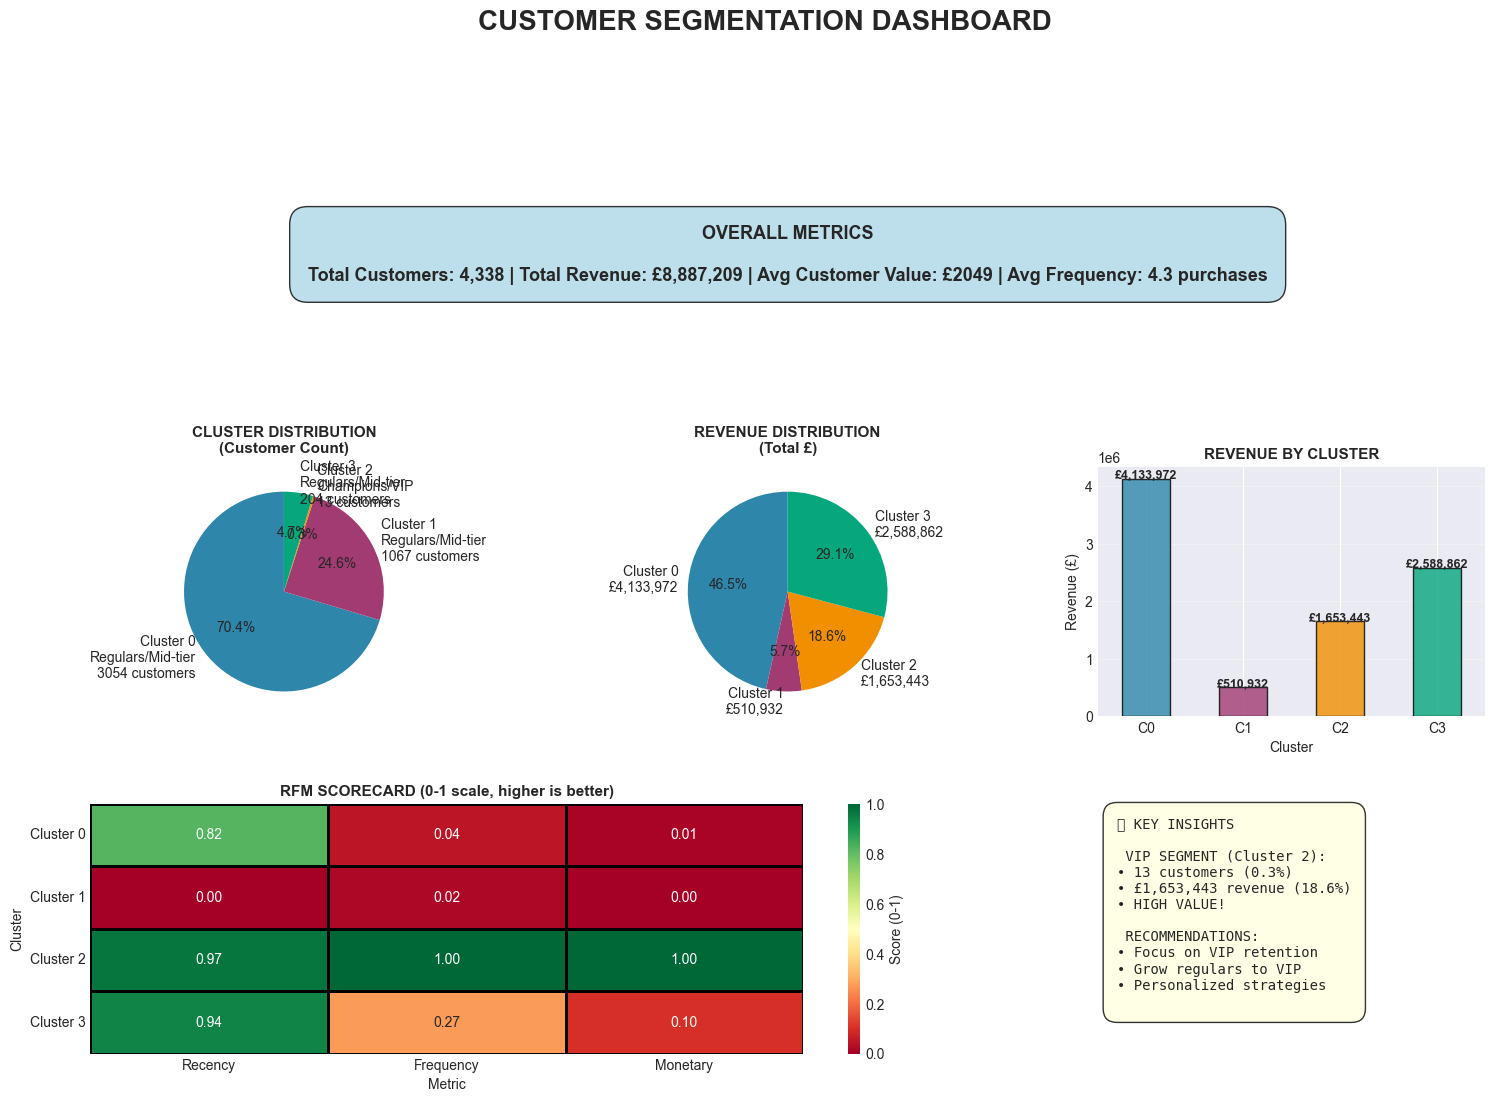

 Dashboard created and saved as customer_segmentation_dashboard.png


In [25]:
# Create a large figure with multiple subplots
fig = plt.figure(figsize=(18, 12))
fig.suptitle('CUSTOMER SEGMENTATION DASHBOARD', fontsize=20, fontweight='bold', y=0.98)

# Create grid
gs = GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.3)

colors = ['#2E86AB', '#A23B72', '#F18F01', '#06A77D']

# ========== TOP ROW: KEY METRICS ==========
ax_metrics = fig.add_subplot(gs[0, :])
ax_metrics.axis('off')

# Create metric boxes
metrics_text = f'''OVERALL METRICS

Total Customers: {total_customers:,} | Total Revenue: £{total_revenue:,.0f} | Avg Customer Value: £{avg_customer_value:.0f} | Avg Frequency: {avg_purchase_frequency:.1f} purchases'''
ax_metrics.text(0.5, 0.5, metrics_text, ha='center', va='center', fontsize=13, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8, pad=1))

# ========== CLUSTER SIZE PIE CHART ==========
ax_pie = fig.add_subplot(gs[1, 0])
cluster_sizes = rfm['Cluster'].value_counts().sort_index()
cluster_labels = [f'Cluster {i}\n{cluster_names[i]}\n{size} customers' 
                  for i, size in cluster_sizes.items()]
ax_pie.pie(cluster_sizes, labels=cluster_labels, autopct='%1.1f%%', colors=colors,
           startangle=90, textprops={'fontsize': 10})
ax_pie.set_title('CLUSTER DISTRIBUTION\n(Customer Count)', fontsize=11, fontweight='bold', pad=10)

# ========== REVENUE PIE CHART ==========
ax_rev_pie = fig.add_subplot(gs[1, 1])
revenue_by_cluster = rfm.groupby('Cluster')['Monetary'].sum().sort_index()
revenue_labels = [f'Cluster {i}\n£{rev:,.0f}' for i, rev in revenue_by_cluster.items()]
ax_rev_pie.pie(revenue_by_cluster, labels=revenue_labels, autopct='%1.1f%%', colors=colors,
               startangle=90, textprops={'fontsize': 10})
ax_rev_pie.set_title('REVENUE DISTRIBUTION\n(Total £)', fontsize=11, fontweight='bold', pad=10)

# ========== REVENUE BAR CHART ==========
ax_bar = fig.add_subplot(gs[1, 2])
revenue_by_cluster.plot(kind='bar', ax=ax_bar, color=colors, edgecolor='black', alpha=0.8)
ax_bar.set_title('REVENUE BY CLUSTER', fontsize=11, fontweight='bold')
ax_bar.set_xlabel('Cluster', fontsize=10)
ax_bar.set_ylabel('Revenue (£)', fontsize=10)
ax_bar.set_xticklabels([f'C{i}' for i in range(4)], rotation=0)
ax_bar.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(revenue_by_cluster):
    ax_bar.text(i, v + 500, f'£{v:,.0f}', ha='center', fontweight='bold', fontsize=9)

# ========== RFM HEATMAP ==========
ax_heatmap = fig.add_subplot(gs[2, :2])

# Create normalized RFM for heatmap
rfm_for_heatmap = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

# Normalize to 0-1 scale for heatmap
rfm_normalized = rfm_for_heatmap.copy()
rfm_normalized['Recency'] = 1 - (rfm_normalized['Recency'] / rfm_normalized['Recency'].max())
rfm_normalized['Frequency'] = rfm_normalized['Frequency'] / rfm_normalized['Frequency'].max()
rfm_normalized['Monetary'] = rfm_normalized['Monetary'] / rfm_normalized['Monetary'].max()

sns.heatmap(rfm_normalized, annot=True, fmt='.2f', cmap='RdYlGn', cbar_kws={'label': 'Score (0-1)'},
            ax=ax_heatmap, linewidths=2, linecolor='black', vmin=0, vmax=1)
ax_heatmap.set_title('RFM SCORECARD (0-1 scale, higher is better)', fontsize=11, fontweight='bold')
ax_heatmap.set_xlabel('Metric', fontsize=10)
ax_heatmap.set_ylabel('Cluster', fontsize=10)
ax_heatmap.set_yticklabels([f'Cluster {i}' for i in range(4)], rotation=0)

# ========== KEY INSIGHTS BOX ==========
ax_insights = fig.add_subplot(gs[2, 2])
ax_insights.axis('off')

# Identify VIP cluster (highest monetary)
vip_cluster = rfm.groupby('Cluster')['Monetary'].mean().idxmax()
vip_size = (rfm['Cluster'] == vip_cluster).sum()
vip_revenue = rfm[rfm['Cluster'] == vip_cluster]['Monetary'].sum()
vip_percent = vip_revenue / total_revenue * 100

insights_text = f'''🎯 KEY INSIGHTS

 VIP SEGMENT (Cluster {vip_cluster}):
• {vip_size} customers ({vip_size/total_customers*100:.1f}%)
• £{vip_revenue:,.0f} revenue ({vip_percent:.1f}%)
• HIGH VALUE!

 RECOMMENDATIONS:
• Focus on VIP retention
• Grow regulars to VIP
• Personalized strategies
'''

ax_insights.text(0.05, 0.95, insights_text, ha='left', va='top', fontsize=10, 
                family='monospace',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8, pad=1))

plt.tight_layout()
plt.savefig('customer_segmentation_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print(' Dashboard created and saved as customer_segmentation_dashboard.png')

## Step 4: Detailed Cluster Analysis

In [22]:
print('\n' + '='*80)
print('CUSTOMER SEGMENTATION ANALYSIS')
print('='*80)

for cluster in sorted(rfm['Cluster'].unique()):
    cluster_data = rfm[rfm['Cluster'] == cluster]
    print(f'\nCLUSTER {cluster}: {cluster_names[cluster].upper()}')
    print(f'  Size: {len(cluster_data)} customers ({len(cluster_data)/total_customers*100:.1f}%)')
    print(f'  Revenue: £{cluster_data["Monetary"].sum():,.0f} ({cluster_data["Monetary"].sum()/total_revenue*100:.1f}%)')
    print(f'  Avg Spend: £{cluster_data["Monetary"].mean():.2f}')
    print(f'  Avg Frequency: {cluster_data["Frequency"].mean():.1f} purchases')
    print(f'  Avg Recency: {cluster_data["Recency"].mean():.0f} days')


CUSTOMER SEGMENTATION ANALYSIS

CLUSTER 0: REGULARS/MID-TIER
  Size: 3054 customers (70.4%)
  Revenue: £4,133,972 (46.5%)
  Avg Spend: £1353.63
  Avg Frequency: 3.7 purchases
  Avg Recency: 44 days

CLUSTER 1: REGULARS/MID-TIER
  Size: 1067 customers (24.6%)
  Revenue: £510,932 (5.7%)
  Avg Spend: £478.85
  Avg Frequency: 1.6 purchases
  Avg Recency: 248 days

CLUSTER 2: CHAMPIONS/VIP
  Size: 13 customers (0.3%)
  Revenue: £1,653,443 (18.6%)
  Avg Spend: £127187.96
  Avg Frequency: 82.5 purchases
  Avg Recency: 7 days

CLUSTER 3: REGULARS/MID-TIER
  Size: 204 customers (4.7%)
  Revenue: £2,588,862 (29.1%)
  Avg Spend: £12690.50
  Avg Frequency: 22.3 purchases
  Avg Recency: 16 days


## Step 5: Strategic Recommendations

In [23]:
print('\n' + '='*80)
print('STRATEGIC RECOMMENDATIONS')
print('='*80)

vip_cluster = rfm.groupby('Cluster')['Monetary'].mean().idxmax()
vip_data = rfm[rfm['Cluster'] == vip_cluster]
regular_data = rfm[rfm['Cluster'] != vip_cluster]

print(f'\n VIP SEGMENT (Cluster {vip_cluster}):')
print(f'  • {len(vip_data)} customers ({len(vip_data)/total_customers*100:.1f}% of base)')
print(f'  • £{vip_data["Monetary"].sum():,.0f} revenue ({vip_data["Monetary"].sum()/total_revenue*100:.1f}% of total)')
print(f'  • {vip_data["Monetary"].mean()/regular_data["Monetary"].mean():.1f}x more valuable than regulars')

print(f'\n ACTION PLAN:')
print(f'\n1. VIP Retention (PRIORITY: HIGH)')
print(f'   → Exclusive loyalty programs')
print(f'   → Personalized offers & early access')
print(f'   → Dedicated support')

print(f'\n2. Grow Regulars to VIP (PRIORITY: HIGH)')
print(f'   → Identify high-potential regulars')
print(f'   → Upsell campaigns')
print(f'   → Cross-sell opportunities')

print(f'\n3. Engagement (PRIORITY: MEDIUM)')
print(f'   → Email marketing')
print(f'   → Personalized recommendations')
print(f'   → Seasonal promotions')

print(f'\n' + '='*80)


STRATEGIC RECOMMENDATIONS

 VIP SEGMENT (Cluster 2):
  • 13 customers (0.3% of base)
  • £1,653,443 revenue (18.6% of total)
  • 76.0x more valuable than regulars

 ACTION PLAN:

1. VIP Retention (PRIORITY: HIGH)
   → Exclusive loyalty programs
   → Personalized offers & early access
   → Dedicated support

2. Grow Regulars to VIP (PRIORITY: HIGH)
   → Identify high-potential regulars
   → Upsell campaigns
   → Cross-sell opportunities

3. Engagement (PRIORITY: MEDIUM)
   → Email marketing
   → Personalized recommendations
   → Seasonal promotions



## Step 6: Export Results

In [24]:
# Create summary
summary_data = []

for cluster in sorted(rfm['Cluster'].unique()):
    cluster_data = rfm[rfm['Cluster'] == cluster]
    summary_data.append({
        'Cluster': cluster,
        'Name': cluster_names[cluster],
        'Customer_Count': len(cluster_data),
        'Total_Revenue': f"£{cluster_data['Monetary'].sum():,.0f}",
        'Avg_Spend': f"£{cluster_data['Monetary'].mean():.2f}",
        'Avg_Frequency': f"{cluster_data['Frequency'].mean():.1f}",
        'Avg_Recency': f"{cluster_data['Recency'].mean():.0f}"
    })

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('customer_segmentation_summary.csv', index=False)

print('\n DASHBOARD COMPLETE!')
print('\nFiles created:')
print('  • customer_segmentation_dashboard.png')
print('  • customer_segmentation_summary.csv')
print('  • customer_segments.csv')



 DASHBOARD COMPLETE!

Files created:
  • customer_segmentation_dashboard.png
  • customer_segmentation_summary.csv
  • customer_segments.csv
